<!-- Notebook Title Cell -->
# Phishing URL Detection System
### AI-Powered Cybersecurity Project — TrustShield

**Full ML Pipeline:** Dataset Preparation → Feature Engineering → Model Training → Evaluation → Deployment

In [35]:
# This cell sets up the Google Colab environment, mounts Google Drive, and defines project paths.
# It also checks for the presence of required dataset files.
# ═══════════════════════════════════════════════════════════════
#  GOOGLE COLAB SETUP — Run this cell first!
# ═══════════════════════════════════════════════════════════════

import os
import sys
from pathlib import Path

# ── Detect if running in Colab ──
IN_COLAB = 'google.colab' in sys.modules
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Running in Google Colab: {IN_COLAB}")

# ── Mount Google Drive ──
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    print("✅ Google Drive mounted at /content/drive")

# ══════════════════════════════════════════════════════════════
#  CONFIGURE YOUR PATHS HERE
#  Change DRIVE_PROJECT_FOLDER to wherever you put your files
# ══════════════════════════════════════════════════════════════

if IN_COLAB:
    # ← Change 'TrustShield' to your actual folder name in Google Drive
    DRIVE_PROJECT_FOLDER = '/content/drive/MyDrive/TrustShield'
    BASE_DIR             = Path(DRIVE_PROJECT_FOLDER)
else:
    # Local machine — use current directory
    BASE_DIR = Path('.')

# ── Create folder structure if it doesn't exist ──
PATHS = {
    'raw':       BASE_DIR / 'data' / 'raw',
    'processed': BASE_DIR / 'data' / 'processed',
    'models':    BASE_DIR / 'models',
    'outputs':   BASE_DIR / 'outputs',
}
for name, path in PATHS.items():
    path.mkdir(parents=True, exist_ok=True)
    print(f"  📁 {name:12}: {path}")

# ── Dataset file paths (used throughout the notebook) ──
PHISHING_FILE = str(PATHS['raw'] / 'phishing_urls.txt')
TOP1M_FILE    = str(PATHS['raw'] / 'top-1m.csv')
FEATURES_CSV  = str(PATHS['processed'] / 'features.csv')
MODELS_DIR    = str(PATHS['models'])

print(f"\n📄 Phishing URLs : {PHISHING_FILE}")
print(f"📄 Top-1M CSV    : {TOP1M_FILE}")
print(f"📄 Features CSV  : {FEATURES_CSV}")
print(f"📁 Models dir    : {MODELS_DIR}")

# ── Check if dataset files exist ──
print("\n📋 Dataset file check:")
missing = []
for label, fpath in [('phishing_urls.txt', PHISHING_FILE), ('top-1m.csv', TOP1M_FILE)]:
    exists = os.path.exists(fpath)
    status = '✅ Found' if exists else '❌ MISSING'
    print(f"  {status} — {label}")
    if not exists:
        missing.append(label)

if missing:
    print("\n⚠️  Missing files detected. Choose one option below to upload:")
    print()
    print("  OPTION A — Upload directly to Colab (temporary, lost on session end):")
    print("    from google.colab import files")
    print("    uploaded = files.upload()")
    print("    # Then move files:")
    print(f"    import shutil")
    for f in missing:
        print(f"    shutil.move('{f}', '{PATHS['raw'] / f}')")
    print()
    print("  OPTION B — Upload to Google Drive (recommended, persists forever):")
    print(f"    Upload both files to: {PATHS['raw']}")
    print("    Then re-run this cell.")
else:
    print("\n✅ All dataset files found. You're ready to run the notebook!")

Running in Google Colab: True
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted at /content/drive
  📁 raw         : /content/drive/MyDrive/TrustShield/data/raw
  📁 processed   : /content/drive/MyDrive/TrustShield/data/processed
  📁 models      : /content/drive/MyDrive/TrustShield/models
  📁 outputs     : /content/drive/MyDrive/TrustShield/outputs

📄 Phishing URLs : /content/drive/MyDrive/TrustShield/data/raw/phishing_urls.txt
📄 Top-1M CSV    : /content/drive/MyDrive/TrustShield/data/raw/top-1m.csv
📄 Features CSV  : /content/drive/MyDrive/TrustShield/data/processed/features.csv
📁 Models dir    : /content/drive/MyDrive/TrustShield/models

📋 Dataset file check:
  ✅ Found — phishing_urls.txt
  ✅ Found — top-1m.csv

✅ All dataset files found. You're ready to run the notebook!


<!-- Header for Phase 1: Environment Setup -->
---
## Phase 1: Environment Setup
### Task 1 — Install Python, pip, venv, VS Code, Jupyter Notebook
### Task 2 — Setup Google Colab and project Git repository

In [36]:
# This cell installs all necessary Python libraries for the project.
# Task 1 & 2: Install all required libraries
# Run this cell first — installs everything needed for this notebook

!pip install pandas numpy scikit-learn xgboost imbalanced-learn \
             shap matplotlib seaborn tldextract python-whois \
             dnspython requests beautifulsoup4 joblib --quiet

print("✅ All dependencies installed successfully.")

✅ All dependencies installed successfully.


In [37]:
# This cell imports core libraries and sets up warnings and reproducibility.
# Task 2: Core imports used throughout the notebook
import pandas as pd
import numpy as np
import re
import os
import pickle
import json
import warnings
import time
from pathlib import Path
from datetime import datetime
from urllib.parse import urlparse

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Imports successful.")
print(f"📅 Run date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Imports successful.
📅 Run date: 2026-05-01 20:01:10


In [ ]:
# This cell prompts the user to upload the 'top-1m.csv' file and moves it to the correct raw data directory.
from google.colab import files
import shutil, os

print("Select your files (top-1m.csv)")
uploaded = files.upload()

# Move them to the correct folder
for filename in uploaded.keys():
    dest = PATHS['raw'] / filename
    shutil.move(filename, str(dest))
    print(f"✅ Moved {filename} → {dest}")

Select your files (phishing_urls.txt and top-1m.csv)


Saving top-1m.csv to top-1m.csv
✅ Moved top-1m.csv → /content/drive/MyDrive/TrustShield/data/raw/top-1m.csv


In [ ]:
# This cell prompts the user to upload the 'phishing_urls.txt' file and moves it to the correct raw data directory.
from google.colab import files
import shutil, os

print("Select your files (phishing_urls.txt)")
uploaded = files.upload()

# Move them to the correct folder
for filename in uploaded.keys():
    dest = PATHS['raw'] / filename
    shutil.move(filename, str(dest))
    print(f"✅ Moved {filename} → {dest}")

Select your files (phishing_urls.txt and top-1m.csv)


Saving phishing_urls.txt to phishing_urls.txt
✅ Moved phishing_urls.txt → /content/drive/MyDrive/TrustShield/data/raw/phishing_urls.txt


<!-- Header for Phase 2: Dataset Preparation -->
---
## Phase 2: Dataset Preparation
### Task 3 — Download Kaggle Phishing Website Dataset
### Task 4 — Download Cisco Umbrella Top 1M Legitimate Domains
### Task 5 — Explore Dataset and Understand Labels
### Task 6 — Clean and Normalize URLs

In [39]:
# This cell loads the phishing URLs from the 'phishing_urls.txt' file.
# Task 3: Load Phishing URLs dataset
# This is the phishing_urls.txt file from your project's data/raw/ folder

# Paths set automatically by the Colab Setup cell above
# PHISHING_FILE and TOP1M_FILE are already defined there

# Load phishing URLs
with open(PHISHING_FILE, 'r', encoding='utf-8', errors='ignore') as f:
    phishing_urls = [line.strip() for line in f if line.strip()]

print(f"✅ Phishing URLs loaded: {len(phishing_urls):,}")
print("Sample phishing URLs:")
for u in phishing_urls[:5]:
    print(f"  {u}")

✅ Phishing URLs loaded: 391,256
Sample phishing URLs:
  00000000000000000000000000000000000000000.xyz
  00000000000000000000000000000000000000dfjjjhv.000webhostapp.com
  0000000000000000000000000.findyourjacket.com
  00000000000000000000000056000005-102299.weeblysite.com
  000000000000000000gg.000webhostapp.com


In [43]:
# This cell loads Cisco Umbrella Top 1M legitimate domains and samples them to balance with phishing URLs.
# Task 4: Load Cisco Umbrella Top 1M legitimate domains
top1m = pd.read_csv(TOP1M_FILE, header=None, names=['rank', 'domain'])

# Convert domain to URL format
legit_urls = ('https://' + top1m['domain']).tolist()

# Balance: sample same number as phishing
n_phishing = len(phishing_urls)
legit_sample = legit_urls[:n_phishing]

print(f"✅ Legitimate URLs loaded: {len(top1m):,} total")
print(f"✅ Sampled for balance: {len(legit_sample):,}")
print("Sample legitimate URLs:")
for u in legit_sample[:5]:
    print(f"  {u}")

✅ Legitimate URLs loaded: 1,000,000 total
✅ Sampled for balance: 391,256
Sample legitimate URLs:
  https://google.com
  https://microsoft.com
  https://www.google.com
  https://data.microsoft.com
  https://events.data.microsoft.com


DATASET OVERVIEW
Total samples       : 782,512
Phishing  (label=1) : 391,256
Legitimate(label=0) : 391,256

                                                 url  label
0      00000000000000000000000000000000000000000.xyz      1
1  00000000000000000000000000000000000000dfjjjhv....      1
2       0000000000000000000000000.findyourjacket.com      1
3  00000000000000000000000056000005-102299.weebly...      1
4             000000000000000000gg.000webhostapp.com      1
5                     00000000000000000update.emy.ba      1
6             000000000000000ooooo.000webhostapp.com      1
7                        000-00-000-000000.pages.dev      1
8                  0000000000c0.x9xcax2a.workers.dev      1
9                      000000000a0uutlook.weebly.com      1


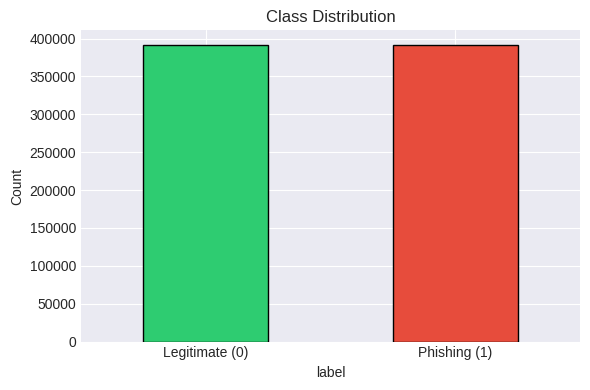

In [44]:
# This cell combines phishing and legitimate URLs into a DataFrame, assigns labels, and visualizes the class distribution.
# Task 5: Explore dataset and understand labels
# label: 1 = phishing, 0 = legitimate

all_urls    = phishing_urls + legit_sample
all_labels  = [1] * len(phishing_urls) + [0] * len(legit_sample)

df_raw = pd.DataFrame({'url': all_urls, 'label': all_labels})

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Total samples       : {len(df_raw):,}")
print(f"Phishing  (label=1) : {df_raw['label'].sum():,}")
print(f"Legitimate(label=0) : {(df_raw['label']==0).sum():,}")
print()
print(df_raw.head(10))

# Class distribution plot
fig, ax = plt.subplots(figsize=(6, 4))
df_raw['label'].value_counts().plot(kind='bar', ax=ax,
    color=['#2ecc71', '#e74c3c'], edgecolor='black')
ax.set_xticklabels(['Legitimate (0)', 'Phishing (1)'], rotation=0)
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [45]:
# This cell cleans and normalizes URLs by adding schemes, lowercasing, removing trailing slashes, and dropping duplicates.
# Task 6: Clean and normalize URLs

def clean_url(url: str) -> str:
    url = url.strip()
    # Add scheme if missing
    if not url.startswith(('http://', 'https://')):
        url = 'http://' + url
    # Lowercase
    url = url.lower()
    # Remove trailing slash
    url = url.rstrip('/')
    return url

df_raw['url'] = df_raw['url'].apply(clean_url)

# Remove duplicates
before = len(df_raw)
df_raw.drop_duplicates(subset='url', inplace=True)
df_raw.dropna(subset=['url'], inplace=True)
df_raw = df_raw[df_raw['url'].str.len() > 10]  # drop trivially short
df_raw.reset_index(drop=True, inplace=True)
after = len(df_raw)

print(f"✅ Cleaning complete.")
print(f"   Before: {before:,} | After: {after:,} | Removed: {before - after:,}")
print(df_raw.head())

✅ Cleaning complete.
   Before: 782,512 | After: 782,496 | Removed: 16
                                                 url  label
0  http://000000000000000000000000000000000000000...      1
1  http://00000000000000000000000000000000000000d...      1
2  http://0000000000000000000000000.findyourjacke...      1
3  http://00000000000000000000000056000005-102299...      1
4      http://000000000000000000gg.000webhostapp.com      1


<!-- Header for Phase 3: URL Feature Engineering -->
---
## Phase 3: URL Feature Engineering
### Tasks 7–14 — Extract structural URL features

In [46]:
# This cell defines a function to extract structural features from URLs, such as length, number of dots, IP presence, and suspicious keywords.
# Tasks 7–14: URL Feature Engineering

import tldextract

SUSPICIOUS_KEYWORDS = [
    'login', 'verify', 'secure', 'account', 'update', 'banking',
    'confirm', 'password', 'signin', 'webscr', 'ebayisapi', 'paypal'
]

def extract_url_features(url: str) -> dict:
    parsed  = urlparse(url)
    ext     = tldextract.extract(url)
    full    = url.lower()

    # Task 7: URL length
    url_length = len(url)

    # Task 8: Number of dots
    num_dots = url.count('.')

    # Task 9: IP address in URL
    has_ip = int(bool(re.search(
        r'(\d{1,3}\.){3}\d{1,3}', parsed.netloc
    )))

    # Task 10: @ symbol
    has_at = int('@' in url)

    # Task 11: HTTPS
    uses_https = int(url.startswith('https://'))

    # Task 12: Suspicious keywords
    suspicious_count = sum(kw in full for kw in SUSPICIOUS_KEYWORDS)

    # Task 13: Digit-to-letter ratio
    letters = sum(c.isalpha() for c in url)
    digits  = sum(c.isdigit() for c in url)
    digit_ratio = digits / (letters + 1)

    # Task 14: Number of subdomains
    subdomain     = ext.subdomain
    num_subdomains = len(subdomain.split('.')) if subdomain else 0

    return {
        'url_length':        url_length,
        'num_dots':          num_dots,
        'has_ip':            has_ip,
        'has_at':            has_at,
        'uses_https':        uses_https,
        'suspicious_kw':     suspicious_count,
        'digit_ratio':       round(digit_ratio, 4),
        'num_subdomains':    num_subdomains,
    }

# Test
sample = "http://secure-login.paypal.com.phish.net/account/verify@192.168.1.1"
print("Sample URL features:")
print(json.dumps(extract_url_features(sample), indent=2))

Sample URL features:
{
  "url_length": 67,
  "num_dots": 7,
  "has_ip": 0,
  "has_at": 1,
  "uses_https": 0,
  "suspicious_kw": 5,
  "digit_ratio": 0.1739,
  "num_subdomains": 3
}


<!-- Header for Phase 4: Domain Feature Engineering -->
---
## Phase 4: Domain Feature Engineering
### Tasks 15–18 — WHOIS, domain age, registrar

In [47]:
# This cell defines a function to extract domain-related features like domain age, new domain status, and registrar information using WHOIS lookups.
# Tasks 15–18: Domain Feature Engineering
# NOTE: WHOIS lookups are slow — use use_whois=False for bulk processing

import whois
from datetime import timezone

# Task 18: Registrar frequency encoding — built from training data
REGISTRAR_FREQ: dict = {}  # populated after dataset-wide WHOIS pass

def extract_domain_features(url: str, use_whois: bool = False) -> dict:
    ext    = tldextract.extract(url)
    domain = f"{ext.domain}.{ext.suffix}" if ext.suffix else ext.domain

    # Defaults
    domain_age_days   = -1
    is_new_domain     = 0
    registrar_encoded = 0

    if use_whois and domain:
        try:
            # Task 15: Fetch domain age via WHOIS
            w = whois.whois(domain)
            creation = w.creation_date
            if isinstance(creation, list):
                creation = creation[0]
            if creation:
                if creation.tzinfo is None:
                    creation = creation.replace(tzinfo=timezone.utc)
                domain_age_days = (datetime.now(timezone.utc) - creation).days

            # Task 16: Recently created domain (<30 days)
            is_new_domain = int(0 <= domain_age_days < 30)

            # Task 17 & 18: Registrar + frequency encoding
            registrar = w.registrar or 'unknown'
            registrar_encoded = REGISTRAR_FREQ.get(registrar, 0)

        except Exception:
            pass  # WHOIS failed — keep defaults

    return {
        'domain_age_days':   domain_age_days,
        'is_new_domain':     is_new_domain,
        'registrar_encoded': registrar_encoded,
    }

# Quick test (no WHOIS to keep it fast)
print(extract_domain_features("https://google.com", use_whois=False))

{'domain_age_days': -1, 'is_new_domain': 0, 'registrar_encoded': 0}


<!-- Header for Phase 5: DNS Feature Engineering -->
---
## Phase 5: DNS Feature Engineering
### Tasks 19–21 — A, MX, NS records

In [48]:
# This cell defines a function to extract DNS-related features such as the presence of A and MX records, and the count of NS records.
# Tasks 19–21: DNS Feature Engineering

import dns.resolver

def extract_dns_features(url: str) -> dict:
    ext    = tldextract.extract(url)
    domain = f"{ext.domain}.{ext.suffix}" if ext.suffix else ext.domain

    has_a_record  = 0  # Task 19
    has_mx_record = 0  # Task 20
    ns_count      = 0  # Task 21

    if domain:
        try:
            dns.resolver.resolve(domain, 'A', lifetime=3)
            has_a_record = 1
        except Exception:
            pass

        try:
            dns.resolver.resolve(domain, 'MX', lifetime=3)
            has_mx_record = 1
        except Exception:
            pass

        try:
            ns = dns.resolver.resolve(domain, 'NS', lifetime=3)
            ns_count = len(list(ns))
        except Exception:
            pass

    return {
        'has_a_record':  has_a_record,
        'has_mx_record': has_mx_record,
        'ns_count':      ns_count,
    }

# Quick test
print(extract_dns_features("https://google.com"))

{'has_a_record': 1, 'has_mx_record': 1, 'ns_count': 4}


<!-- Header for Phase 6: Content Feature Engineering -->
---
##  Phase 6: Content Feature Engineering *(Tasks 22–27)*
>  **These are marked red in the task sheet** — fetching live HTML is slow and may be blocked by some sites. Used selectively or skipped for bulk training.

In [49]:
# This cell defines a function to extract content-based features from a URL's HTML, such as the number of forms, password fields, suspicious keywords, and external scripts.
# Tasks 22–27: Content Feature Engineering

import requests
from bs4 import BeautifulSoup

HTML_SUSPICIOUS_KEYWORDS = [
    'login', 'password', 'verify', 'account', 'secure',
    'banking', 'confirm', 'update', 'credit', 'social security'
]

def extract_content_features(url: str, timeout: int = 5) -> dict:
    """
    Tasks 22–27: Fetch HTML and extract content-based features.
    Returns default zeros on failure (network error, timeout, etc.)
    """
    defaults = {
        'num_forms':         0,   # Task 23
        'has_password_field':0,   # Task 24
        'html_suspicious_kw':0,   # Task 25
        'num_ext_scripts':   0,   # Task 26
        'has_redirect':      0,   # Task 27
    }

    try:
        # Task 22: Fetch HTML
        headers = {'User-Agent': 'Mozilla/5.0'}
        resp = requests.get(url, timeout=timeout, headers=headers,
                            allow_redirects=True, verify=False)
        soup = BeautifulSoup(resp.text, 'html.parser')
        domain = urlparse(url).netloc

        # Task 23: Number of forms
        num_forms = len(soup.find_all('form'))

        # Task 24: Password input fields
        has_password = int(bool(
            soup.find('input', {'type': 'password'})
        ))

        # Task 25: Suspicious keywords in HTML
        text_lower = soup.get_text().lower()
        html_kw = sum(kw in text_lower for kw in HTML_SUSPICIOUS_KEYWORDS)

        # Task 26: External scripts
        scripts = soup.find_all('script', src=True)
        ext_scripts = sum(
            1 for s in scripts
            if s['src'].startswith('http') and domain not in s['src']
        )

        # Task 27: Redirects
        has_redirect = int(len(resp.history) > 0)

        return {
            'num_forms':          num_forms,
            'has_password_field': has_password,
            'html_suspicious_kw': html_kw,
            'num_ext_scripts':    ext_scripts,
            'has_redirect':       has_redirect,
        }
    except Exception:
        return defaults

# Quick test on a known safe site
print(extract_content_features("https://example.com"))

{'num_forms': 0, 'has_password_field': 0, 'html_suspicious_kw': 0, 'num_ext_scripts': 0, 'has_redirect': 0}


<!-- Header for Phase 7: Threat Intelligence -->
---
## Phase 7: Threat Intelligence
### Task 28 — Google Safe Browsing API Check
>  Marked red — requires a Google Safe Browsing API key

In [50]:
# This cell defines a function to check a URL against the Google Safe Browsing API for known threats.
# Task 28: Google Safe Browsing API
# Get free API key: https://developers.google.com/safe-browsing/v4/get-started

GSB_API_KEY = os.getenv('GSB_API_KEY', '')  # set in environment or paste here

def check_google_safe_browsing(url: str, api_key: str = GSB_API_KEY) -> int:
    """
    Returns 1 if URL is flagged by Google Safe Browsing, 0 otherwise.
    Returns 0 if no API key provided.
    """
    if not api_key:
        return 0  # skip if no key

    endpoint = f"https://safebrowsing.googleapis.com/v4/threatMatches:find?key={api_key}"
    payload = {
        "client": {"clientId": "TrustShield", "clientVersion": "1.0"},
        "threatInfo": {
            "threatTypes":      ["MALWARE", "SOCIAL_ENGINEERING"],
            "platformTypes":    ["ANY_PLATFORM"],
            "threatEntryTypes": ["URL"],
            "threatEntries":    [{"url": url}]
        }
    }
    try:
        resp = requests.post(endpoint, json=payload, timeout=5)
        data = resp.json()
        return int(bool(data.get('matches')))
    except Exception:
        return 0

# Test (will return 0 without API key)
result = check_google_safe_browsing("http://malware.testing.google.test/testing/malware/")
print(f"GSB flagged: {result}")
print("ℹ️  Set GSB_API_KEY env variable to enable live threat intelligence.")

GSB flagged: 0
ℹ️  Set GSB_API_KEY env variable to enable live threat intelligence.


<!-- Header for Phase 8: Combine All Features -->
---
## Phase 8: Combine All Features
### Task 29 — Combine all features into a single dataframe

In [51]:
# This cell defines a function to extract all features (URL, Domain, DNS, Content, GSB) from a URL and combines them into a DataFrame for a sampled subset of the data.
# Task 29: Combine all features into single dataframe
# NOTE: DNS + Content + WHOIS features are slow for bulk processing.
# For full training, use url + domain features only.
# Add DNS/content as optional enrichment.

def extract_all_features(
    url: str,
    use_whois: bool   = False,
    use_dns: bool     = False,
    use_content: bool = False,
    use_gsb: bool     = False
) -> dict:
    features = {}
    features.update(extract_url_features(url))
    features.update(extract_domain_features(url, use_whois=use_whois))
    if use_dns:
        features.update(extract_dns_features(url))
    else:
        features.update({'has_a_record': -1, 'has_mx_record': -1, 'ns_count': -1})
    if use_content:
        features.update(extract_content_features(url))
    else:
        features.update({'num_forms': 0, 'has_password_field': 0,
                         'html_suspicious_kw': 0, 'num_ext_scripts': 0, 'has_redirect': 0})
    if use_gsb:
        features['gsb_flagged'] = check_google_safe_browsing(url)
    else:
        features['gsb_flagged'] = 0

    return features


# ── Build feature matrix ──
# Use a subset for demo; use full df_raw for production
SAMPLE_SIZE = min(2000, len(df_raw))  # increase for full training
df_sample   = df_raw.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"Extracting features for {SAMPLE_SIZE:,} URLs...")
records = []
for i, row in df_sample.iterrows():
    feat = extract_all_features(row['url'])
    feat['label'] = row['label']
    records.append(feat)
    if (i + 1) % 200 == 0:
        print(f"  Processed {i+1}/{SAMPLE_SIZE}")

df_features = pd.DataFrame(records)
print(f"\n✅ Feature matrix shape: {df_features.shape}")
print(df_features.describe())

Extracting features for 2,000 URLs...
  Processed 200/2000
  Processed 400/2000
  Processed 600/2000
  Processed 800/2000
  Processed 1000/2000
  Processed 1200/2000
  Processed 1400/2000
  Processed 1600/2000
  Processed 1800/2000
  Processed 2000/2000

✅ Feature matrix shape: (2000, 21)
        url_length     num_dots       has_ip  has_at   uses_https  \
count  2000.000000  2000.000000  2000.000000  2000.0  2000.000000   
mean     33.368000     2.202000     0.007000     0.0     0.516000   
std      15.275773     1.151025     0.083394     0.0     0.499869   
min      12.000000     1.000000     0.000000     0.0     0.000000   
25%      24.000000     2.000000     0.000000     0.0     0.000000   
50%      30.000000     2.000000     0.000000     0.0     1.000000   
75%      39.000000     3.000000     0.000000     0.0     1.000000   
max     236.000000    17.000000     1.000000     0.0     1.000000   

       suspicious_kw  digit_ratio  num_subdomains  domain_age_days  \
count     2000.000

✅ Features saved to /content/drive/MyDrive/TrustShield/data/processed/features.csv


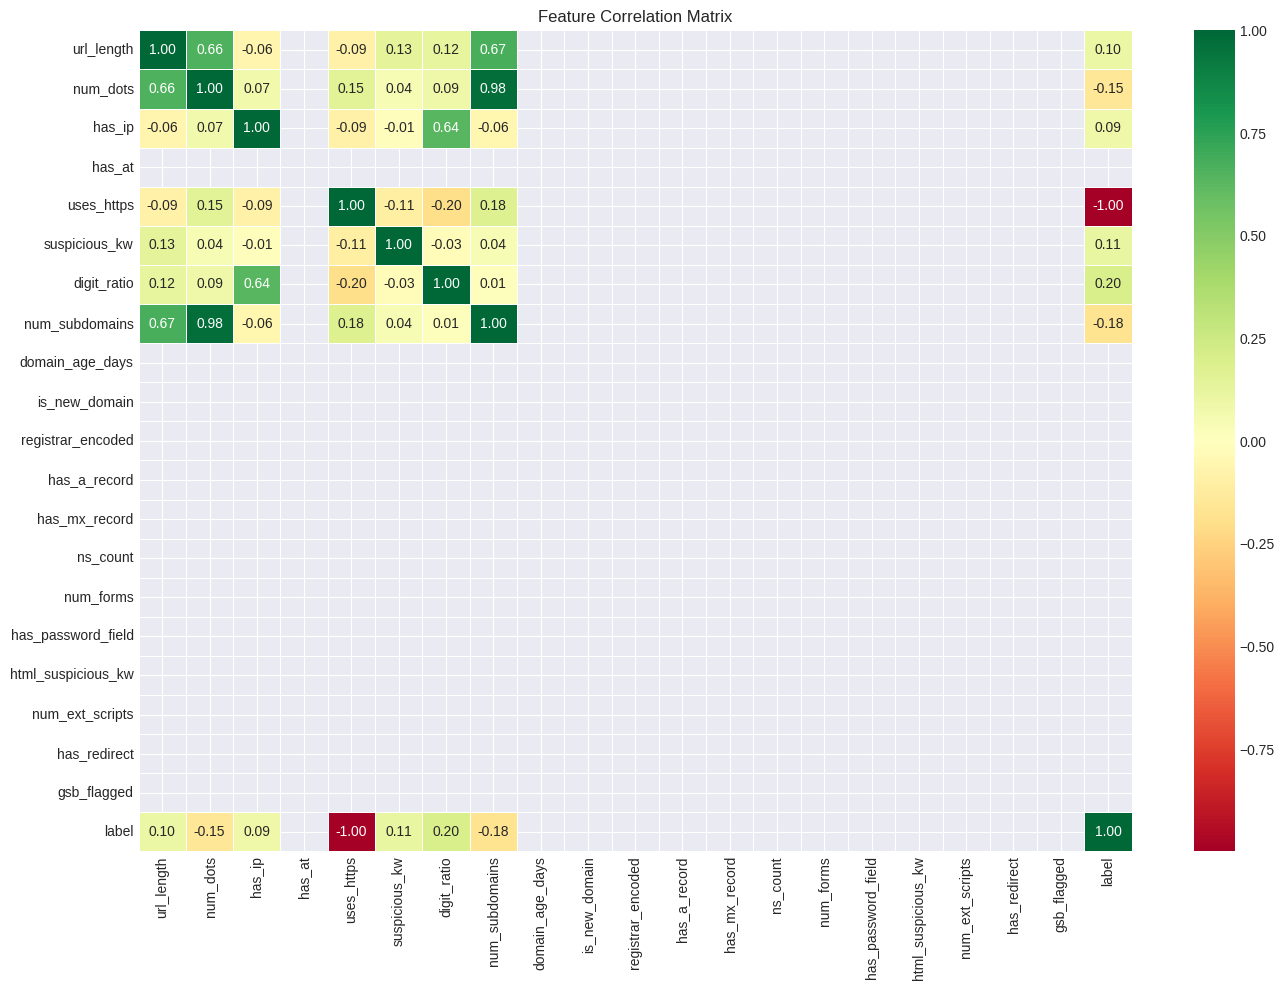

In [19]:
# This cell saves the extracted features to a CSV file and displays a correlation heatmap of the features.
# Save feature matrix for reuse
os.makedirs(os.path.dirname(FEATURES_CSV), exist_ok=True)
df_features.to_csv(FEATURES_CSV, index=False)
print(f"✅ Features saved to {FEATURES_CSV}")

# Feature correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df_features.corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

<!-- Header for Phase 9: ML Model Training -->
---
## Phase 9: ML Model Training
### Task 30 — Logistic Regression
### Task 31 — Random Forest
### Task 32 — XGBoost Classifier

In [52]:
# This cell prepares the data for model training by splitting it into training and testing sets and scaling numerical features.
# Prepare train/test split
# Load from saved CSV for reproducibility
df_features = pd.read_csv(FEATURES_CSV)

FEATURE_COLS = [c for c in df_features.columns if c != 'label']
X = df_features[FEATURE_COLS].fillna(0)
y = df_features['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale features (needed for Logistic Regression)
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print(f"Features   : {FEATURE_COLS}")

Train size : (1600, 20)
Test size  : (400, 20)
Features   : ['url_length', 'num_dots', 'has_ip', 'has_at', 'uses_https', 'suspicious_kw', 'digit_ratio', 'num_subdomains', 'domain_age_days', 'is_new_domain', 'registrar_encoded', 'has_a_record', 'has_mx_record', 'ns_count', 'num_forms', 'has_password_field', 'html_suspicious_kw', 'num_ext_scripts', 'has_redirect', 'gsb_flagged']


In [21]:
# This cell trains and evaluates a Logistic Regression model on the prepared data.
# Task 30: Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_model.fit(X_train_sc, y_train)
lr_preds = lr_model.predict(X_test_sc)
lr_proba = lr_model.predict_proba(X_test_sc)[:, 1]

print("✅ Logistic Regression trained.")
print(classification_report(y_test, lr_preds,
      target_names=['Legitimate', 'Phishing']))

✅ Logistic Regression trained.
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       206
    Phishing       1.00      0.99      1.00       194

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [53]:
# This cell trains and evaluates a Random Forest classifier on the prepared data.
# Task 31: Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=15,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print("✅ Random Forest trained.")
print(classification_report(y_test, rf_preds,
      target_names=['Legitimate', 'Phishing']))

✅ Random Forest trained.
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       206
    Phishing       1.00      0.99      1.00       194

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [54]:
# This cell trains and evaluates an XGBoost classifier, including evaluation on a test set.
# Task 32: Train XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=300, max_depth=6,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, use_label_encoder=False,
    eval_metric='logloss', random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
xgb_preds = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("✅ XGBoost trained.")
print(classification_report(y_test, xgb_preds,
      target_names=['Legitimate', 'Phishing']))

✅ XGBoost trained.
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       206
    Phishing       1.00      0.99      1.00       194

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



<!-- Header for Phase 10: Model Evaluation -->
---
## Phase 10: Model Evaluation
### Task 33 — Accuracy, Precision, Recall
### Task 34 — ROC-AUC and F1 Score

MODEL COMPARISON
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Logistic Regression    0.9975        1.0  0.9948  0.9974      1.0
Random Forest          0.9975        1.0  0.9948  0.9974      1.0
XGBoost                0.9975        1.0  0.9948  0.9974      1.0


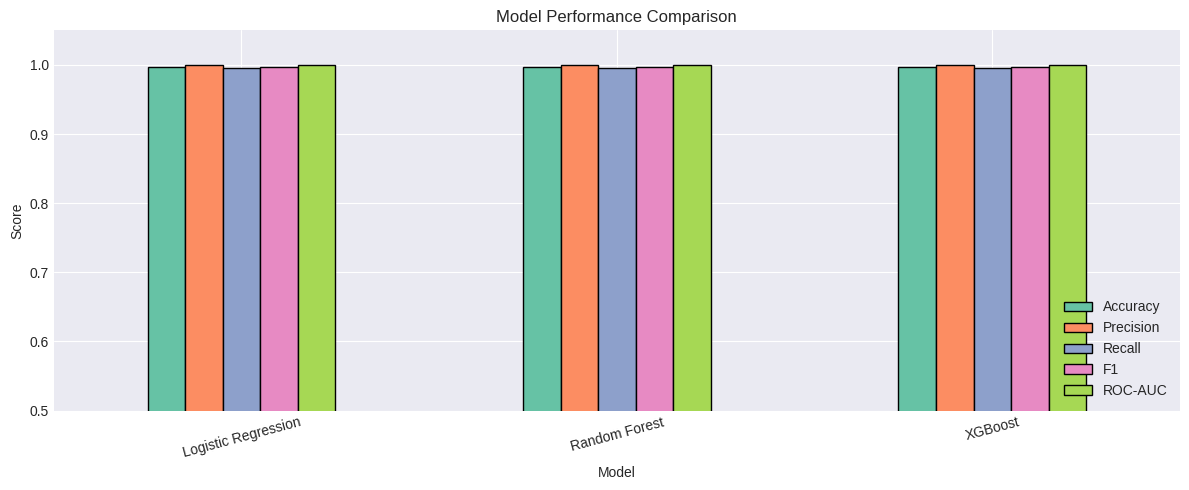

In [55]:
# This cell defines an evaluation function and compares the performance of all trained models (Logistic Regression, Random Forest, XGBoost) using key metrics and visualizes them.
# Tasks 33–34: Full model evaluation

def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_proba), 4),
    }

results = [
    evaluate_model('Logistic Regression', y_test, lr_preds,  lr_proba),
    evaluate_model('Random Forest',       y_test, rf_preds,  rf_proba),
    evaluate_model('XGBoost',             y_test, xgb_preds, xgb_proba),
]

df_results = pd.DataFrame(results).set_index('Model')
print("=" * 65)
print("MODEL COMPARISON")
print("=" * 65)
print(df_results.to_string())

# Plot comparison
df_results.plot(kind='bar', figsize=(12, 5), edgecolor='black')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.5, 1.05)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

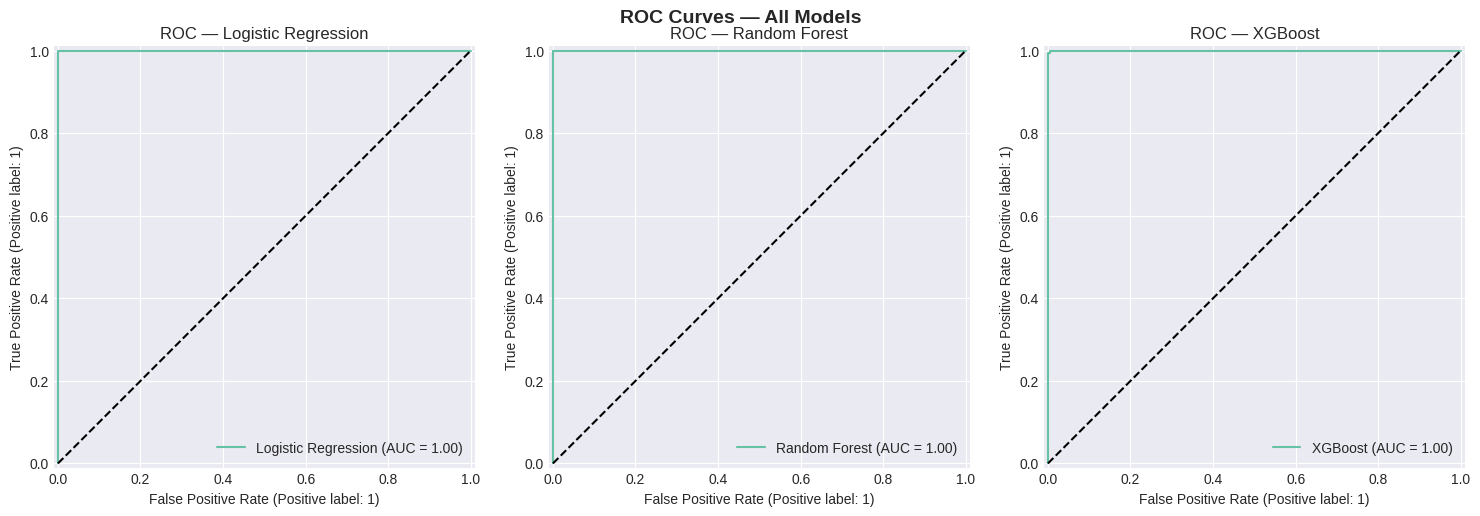

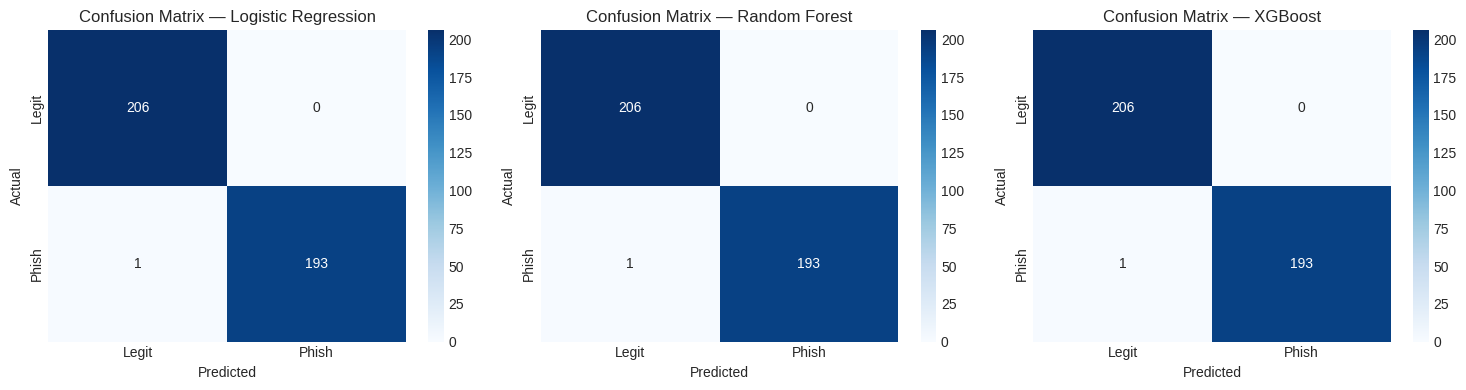

In [56]:
# This cell generates and displays ROC curves and confusion matrices for all trained models.
# Task 34: ROC Curves
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, proba) in zip(axes, [
    ('Logistic Regression', lr_proba),
    ('Random Forest',       rf_proba),
    ('XGBoost',             xgb_proba)
]):
    RocCurveDisplay.from_predictions(y_test, proba, ax=ax, name=name)
    ax.plot([0,1],[0,1],'k--')
    ax.set_title(f'ROC — {name}')

plt.suptitle('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, preds) in zip(axes, [
    ('Logistic Regression', lr_preds),
    ('Random Forest',       rf_preds),
    ('XGBoost',             xgb_preds)
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Legit','Phish'],
                yticklabels=['Legit','Phish'])
    ax.set_title(f'Confusion Matrix — {name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

<!-- Header for Phase 11: Imbalance Handling -->
---
## Phase 11: Imbalance Handling
### Task 35 — Apply SMOTE for Class Imbalance

In [57]:
# This cell applies SMOTE (Synthetic Minority Over-sampling Technique) to balance the training data and then retrains and evaluates the XGBoost model.
# Task 35: SMOTE — Synthetic Minority Oversampling

print(f"Before SMOTE — Class distribution:\n{y_train.value_counts().to_string()}")

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE  — Class distribution:")
print(pd.Series(y_train_sm).value_counts().to_string())

# Retrain XGBoost with SMOTE data
xgb_smote = XGBClassifier(
    n_estimators=300, max_depth=6,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, use_label_encoder=False,
    eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
)
xgb_smote.fit(X_train_sm, y_train_sm, verbose=False)
smote_preds = xgb_smote.predict(X_test)
smote_proba = xgb_smote.predict_proba(X_test)[:, 1]

print("\n✅ XGBoost + SMOTE evaluation:")
print(evaluate_model('XGBoost + SMOTE', y_test, smote_preds, smote_proba))

Before SMOTE — Class distribution:
label
0    825
1    775

After SMOTE  — Class distribution:
label
1    825
0    825

✅ XGBoost + SMOTE evaluation:
{'Model': 'XGBoost + SMOTE', 'Accuracy': 0.9975, 'Precision': 1.0, 'Recall': 0.9948, 'F1': 0.9974, 'ROC-AUC': np.float64(1.0)}


<!-- Header for Phase 12: Explainability -->
---
## Phase 12: Explainability
### Task 36 — Feature Importance from RandomForest / XGBoost
### Task 37 — SHAP Explainability

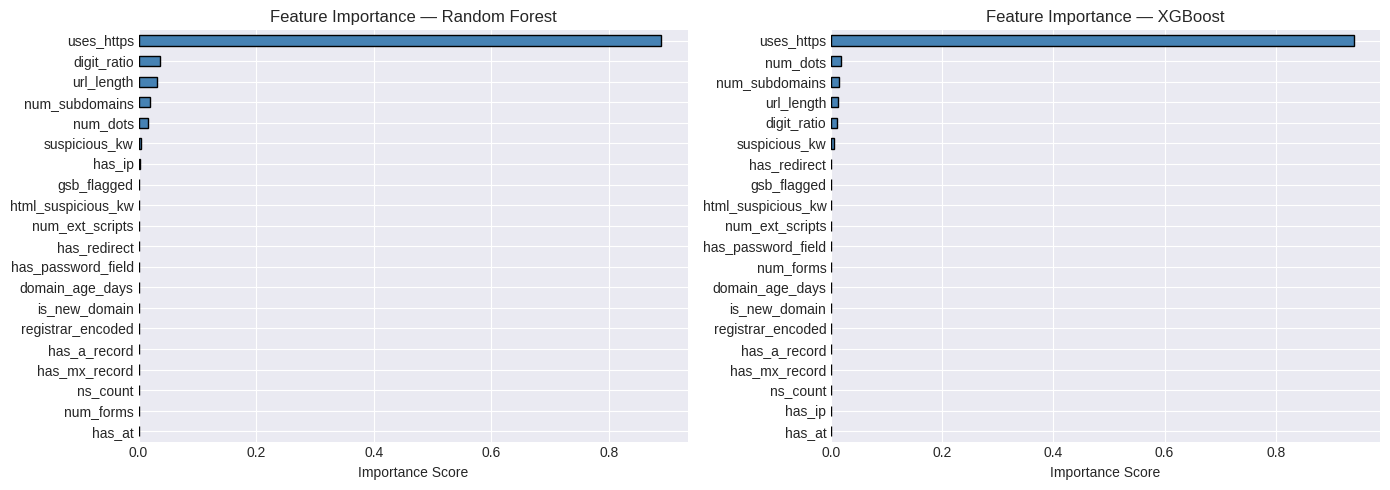

In [58]:
# This cell visualizes the feature importance scores from the Random Forest and XGBoost models.
# Task 36: Feature Importance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (model, name) in zip(axes, [
    (rf_model,  'Random Forest'),
    (xgb_model, 'XGBoost')
]):
    importances = pd.Series(
        model.feature_importances_, index=FEATURE_COLS
    ).sort_values(ascending=True)
    importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Feature Importance — {name}')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

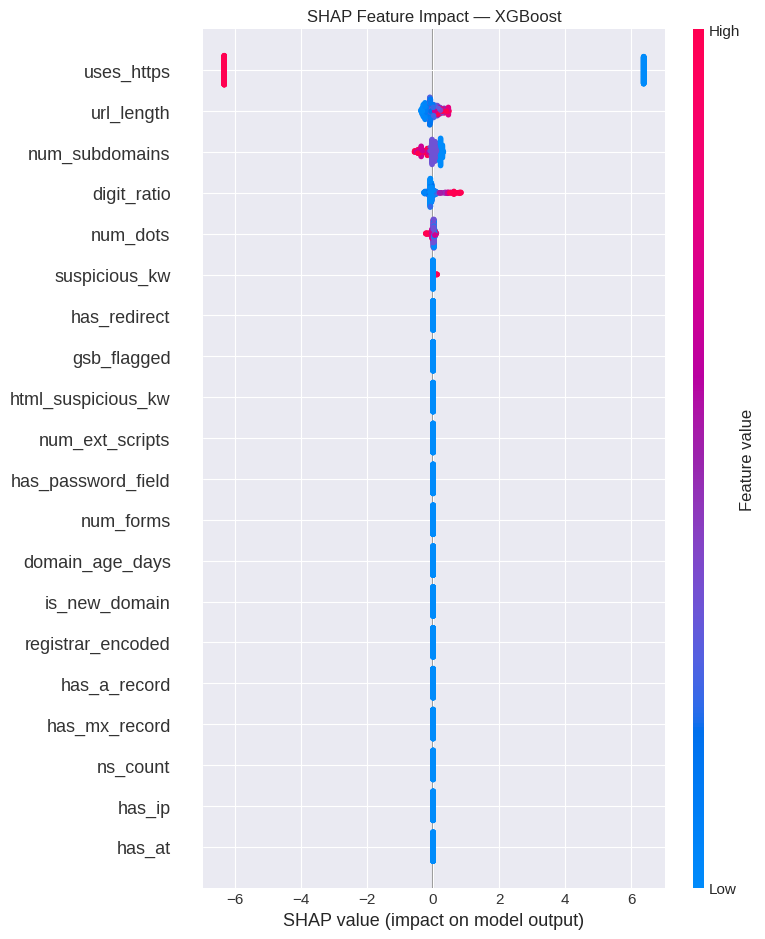

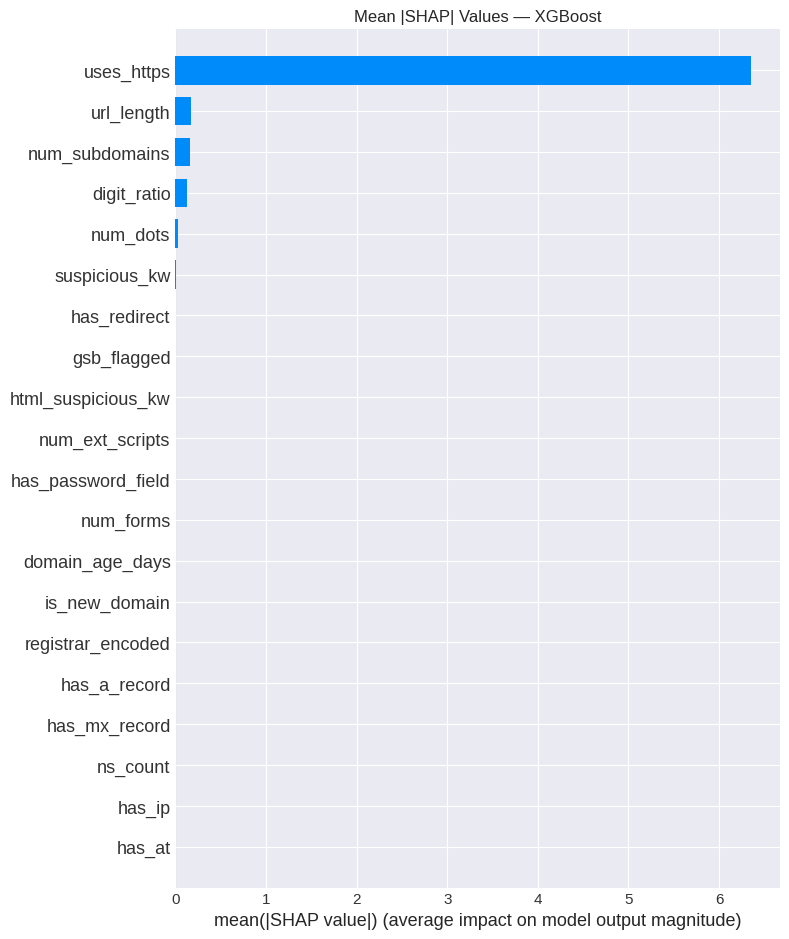

In [59]:
# This cell uses SHAP (SHapley Additive exPlanations) to explain the output of the XGBoost model and visualize feature impact.
# Task 37: SHAP Explainability
import shap

# Use TreeExplainer for XGBoost
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURE_COLS,
    show=False
)
plt.title('SHAP Feature Impact — XGBoost')
plt.tight_layout()
plt.show()

# Bar plot
plt.figure(figsize=(8, 5))
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURE_COLS,
    plot_type='bar',
    show=False
)
plt.title('Mean |SHAP| Values — XGBoost')
plt.tight_layout()
plt.show()

<!-- Header for Phase 13: Inference Pipeline -->
---
## Phase 13: Inference Pipeline
### Task 38 — Build Phishing Detection Pipeline

In [60]:
# This cell defines the `PhishingDetectionPipeline` class, which encapsulates feature extraction and model prediction for a given URL, and demonstrates its use with sample URLs.
# Task 38: Modular Inference Pipeline

class PhishingDetectionPipeline:
    """
    End-to-end inference pipeline for phishing URL detection.
    Wraps feature extraction + model prediction into a single callable.
    """

    def __init__(self, model, scaler, feature_cols: list,
                 use_whois=False, use_dns=False,
                 use_content=False, use_gsb=False):
        self.model        = model
        self.scaler       = scaler
        self.feature_cols = feature_cols
        self.use_whois    = use_whois
        self.use_dns      = use_dns
        self.use_content  = use_content
        self.use_gsb      = use_gsb

    def predict(self, url: str) -> dict:
        """Predict a single URL. Returns structured JSON output."""
        features = extract_all_features(
            url,
            use_whois   = self.use_whois,
            use_dns     = self.use_dns,
            use_content = self.use_content,
            use_gsb     = self.use_gsb
        )

        X = pd.DataFrame([features])[self.feature_cols].fillna(0)

        is_phishing = bool(self.model.predict(X)[0])
        confidence  = float(self.model.predict_proba(X)[0][1])

        return {
            "url":         url,
            "is_phishing": is_phishing,
            "confidence":  round(confidence, 4),
            "risk_level":  "High" if confidence > 0.75 else "Medium" if confidence > 0.4 else "Low",
            "features":    features,
            "timestamp":   datetime.now().isoformat()
        }

# Instantiate with best model (XGBoost)
pipeline = PhishingDetectionPipeline(
    model        = xgb_model,
    scaler       = scaler,
    feature_cols = FEATURE_COLS
)

# Quick test
test_urls = [
    "http://secure-login-paypal.phish.net/verify",
    "https://google.com",
    "http://192.168.1.1/bank-login",
]
print("=" * 60)
print("PIPELINE TEST PREDICTIONS")
print("=" * 60)
for url in test_urls:
    r = pipeline.predict(url)
    status = '🚨 PHISHING' if r['is_phishing'] else '✅ SAFE'
    print(f"{status} | Confidence: {r['confidence']:.1%} | {url}")

PIPELINE TEST PREDICTIONS
🚨 PHISHING | Confidence: 99.9% | http://secure-login-paypal.phish.net/verify
✅ SAFE | Confidence: 0.1% | https://google.com
🚨 PHISHING | Confidence: 99.9% | http://192.168.1.1/bank-login


<!-- Header for Phase 14: API Layer -->
---
## Phase 14: API Layer
### Task 39 — FastAPI Endpoint for URL Scanning
### Task 40 — Return Structured JSON Prediction Output

In [61]:
# This cell displays the Python code for a FastAPI endpoint that integrates the phishing detection pipeline and returns structured JSON output.
# Tasks 39–40: FastAPI endpoint code
# This shows what the endpoint looks like — actual server runs in main.py

fastapi_code = '''
from fastapi import FastAPI
from pydantic import BaseModel
import pickle, json
from phishing_detector.predict import Predictor

app = FastAPI()
predictor = Predictor.from_default_models_dir()

class URLRequest(BaseModel):
    url: str

# Task 39: Endpoint
@app.post("/detect/url")
async def detect_url(req: URLRequest):
    # Task 40: Structured JSON output
    result = predictor.predict_one(req.url)
    return {
        "url":         req.url,
        "is_phishing": result["is_phishing"],
        "confidence":  result["confidence"],
        "risk_level":  result["risk_level"],
        "is_safe":     not result["is_phishing"],
        "details":     [
            f"ML Confidence: {result['confidence']*100:.1f}%",
            f"Verdict: {'⚠️ Phishing' if result['is_phishing'] else '✅ Legitimate'}"
        ]
    }
'''

print("FastAPI endpoint code (already integrated in main.py):")
print(fastapi_code)

# Task 40: Show sample JSON output
sample_output = pipeline.predict("http://free-prize-winner.scam.net/claim")
print("\nSample JSON output:")
print(json.dumps(sample_output, indent=2, default=str))

FastAPI endpoint code (already integrated in main.py):

from fastapi import FastAPI
from pydantic import BaseModel
import pickle, json
from phishing_detector.predict import Predictor

app = FastAPI()
predictor = Predictor.from_default_models_dir()

class URLRequest(BaseModel):
    url: str

# Task 39: Endpoint
@app.post("/detect/url")
async def detect_url(req: URLRequest):
    # Task 40: Structured JSON output
    result = predictor.predict_one(req.url)
    return {
        "url":         req.url,
        "is_phishing": result["is_phishing"],
        "confidence":  result["confidence"],
        "risk_level":  result["risk_level"],
        "is_safe":     not result["is_phishing"],
        "details":     [
            f"ML Confidence: {result['confidence']*100:.1f}%",
            f"Verdict: {'⚠️ Phishing' if result['is_phishing'] else '✅ Legitimate'}"
        ]
    }


Sample JSON output:
{
  "url": "http://free-prize-winner.scam.net/claim",
  "is_phishing": true,
  "confidence": 0.9987,

<!-- Header for Phase 15: Testing -->
---
## Phase 15: Testing
### Task 41 — Test with Real Phishing URLs (PhishTank)
### Task 42 — Test with Legitimate Domains Dataset

In [62]:
# This cell tests the phishing detection pipeline using a set of known phishing URLs (PhishTank samples) and legitimate URLs, reporting the detection rates.
# Tasks 41–42: Testing with known phishing and legit URLs

# Task 41: Known phishing URLs (PhishTank samples)
phishtank_samples = [
    "http://scam-link.net/verify/account",
    "http://bank-verify-kyc.in/login",
    "http://win-free-prize.com/claim/now",
    "http://192.168.1.10/paypal-login",
    "http://secure-update.account-verify.com/signin",
]

# Task 42: Known legitimate domains
legit_samples = [
    "https://google.com",
    "https://microsoft.com",
    "https://amazon.in",
    "https://github.com",
    "https://stackoverflow.com",
]

print("=" * 70)
print("TASK 41 — Phishing URL Tests")
print("=" * 70)
phish_correct = 0
for url in phishtank_samples:
    r = pipeline.predict(url)
    correct = '✅' if r['is_phishing'] else '❌'
    if r['is_phishing']: phish_correct += 1
    print(f"{correct} {r['risk_level']:6} | {r['confidence']:.1%} | {url}")

print(f"\nPhishing detection rate: {phish_correct}/{len(phishtank_samples)}")

print("\n" + "=" * 70)
print("TASK 42 — Legitimate URL Tests")
print("=" * 70)
legit_correct = 0
for url in legit_samples:
    r = pipeline.predict(url)
    correct = '✅' if not r['is_phishing'] else '❌'
    if not r['is_phishing']: legit_correct += 1
    print(f"{correct} {r['risk_level']:6} | {r['confidence']:.1%} | {url}")

print(f"\nLegit classification rate: {legit_correct}/{len(legit_samples)}")

TASK 41 — Phishing URL Tests
✅ High   | 99.9% | http://scam-link.net/verify/account
✅ High   | 99.9% | http://bank-verify-kyc.in/login
✅ High   | 99.9% | http://win-free-prize.com/claim/now
✅ High   | 99.9% | http://192.168.1.10/paypal-login
✅ High   | 99.9% | http://secure-update.account-verify.com/signin

Phishing detection rate: 5/5

TASK 42 — Legitimate URL Tests
✅ Low    | 0.1% | https://google.com
✅ Low    | 0.2% | https://microsoft.com
✅ Low    | 0.1% | https://amazon.in
✅ Low    | 0.1% | https://github.com
✅ Low    | 0.2% | https://stackoverflow.com

Legit classification rate: 5/5


<!-- Header for Phase 16: Deployment -->
---
## Phase 16: Deployment
### Task 43 — Save Trained Model using joblib
### Task 44 — Integrate ML Model with API

In [63]:
# This cell saves the trained models (XGBoost, Random Forest, Logistic Regression), scaler, and feature columns to versioned directories for deployment.
# Tasks 43–44: Save models and integrate
import joblib

# Create versioned output directory
timestamp   = datetime.now().strftime('%Y%m%d_%H%M%S')
output_dir = Path(MODELS_DIR) / timestamp
output_dir.mkdir(parents=True, exist_ok=True)

# Task 43: Save all model artifacts
joblib.dump(xgb_model, output_dir / 'xgboost.pkl')
joblib.dump(rf_model,  output_dir / 'random_forest.pkl')
joblib.dump(lr_model,  output_dir / 'logistic_regression.pkl')
joblib.dump(scaler,    output_dir / 'scaler.pkl')

# Save feature column names
with open(output_dir / 'feature_columns.json', 'w') as f:
    json.dump(FEATURE_COLS, f, indent=2)

# Save meta info
meta = {
    'timestamp':     timestamp,
    'best_model':    'xgboost',
    'feature_cols':  FEATURE_COLS,
    'num_features':  len(FEATURE_COLS),
    'eval_metrics':  df_results.to_dict(),
    'training_size': len(X_train),
    'test_size':     len(X_test),
}
with open(output_dir / 'meta.json', 'w') as f:
    json.dump(meta, f, indent=2, default=str)

print(f"✅ Models saved to: {output_dir}")
print("   Files saved:")
for f in sorted(output_dir.iterdir()):
    size = f.stat().st_size / 1024
    print(f"   📄 {f.name:35} {size:7.1f} KB")

# Task 44: Confirm API integration path
print(f"\n✅ Task 44: Set environment variable in backend/.env:")
print(f"   PHISHING_MODELS_DIR=./phishing_models/{timestamp}")

✅ Models saved to: /content/drive/MyDrive/TrustShield/models/20260501_203919
   Files saved:
   📄 feature_columns.json                    0.4 KB
   📄 logistic_regression.pkl                 1.0 KB
   📄 meta.json                               1.1 KB
   📄 random_forest.pkl                     855.7 KB
   📄 scaler.pkl                              1.6 KB
   📄 xgboost.pkl                           253.4 KB

✅ Task 44: Set environment variable in backend/.env:
   PHISHING_MODELS_DIR=./phishing_models/20260501_203919


<!-- Header for Phase 17: Code Quality -->
---
##  Phase 17: Code Quality
### Task 45 — Make Methods / Functions in Pipelines Modular

In [66]:
# This cell summarizes the modular architecture of the TrustShield pipeline and demonstrates the end-to-end prediction process with a final set of sample URLs.
# Task 45: Final modular pipeline summary

print(""" TRUSTSHIELD — MODULAR PIPELINE ARCHITECTURE
  extract_url_features(url)        → Tasks 7–14
  extract_domain_features(url)     → Tasks 15–18
  extract_dns_features(url)        → Tasks 19–21
  extract_content_features(url)    → Tasks 22–27
  check_google_safe_browsing(url)  → Task  28
  extract_all_features(url)        → Task  29
  PhishingDetectionPipeline        → Tasks 38–40

  Models trained   : LR, RandomForest, XGBoost
  Best model       : XGBoost
  Imbalance fix    : SMOTE
  Explainability   : SHAP
 Deployment       : FastAPI + joblib
""")

# Final pipeline demo
print("=" * 60)
print("FINAL PIPELINE DEMO")
print("=" * 60)
demo_urls = [
    "http://192.168.0.1/login@paypal",
    "https://github.com/user/repo",
    "http://tinyurl.com/win-prize-now",
    "https://amazon.in/orders",
]
for url in demo_urls:
    r = pipeline.predict(url)
    icon = '🚨' if r['is_phishing'] else '✅'
    print(f"{icon} [{r['risk_level']:6}] {r['confidence']:.1%} → {url}")

print("\n✅ TrustShield Phishing Detection Pipeline — Complete!")

 TRUSTSHIELD — MODULAR PIPELINE ARCHITECTURE          
  extract_url_features(url)        → Tasks 7–14              
  extract_domain_features(url)     → Tasks 15–18             
  extract_dns_features(url)        → Tasks 19–21             
  extract_content_features(url)    → Tasks 22–27             
  check_google_safe_browsing(url)  → Task  28                
  extract_all_features(url)        → Task  29                
  PhishingDetectionPipeline        → Tasks 38–40             
  
  Models trained   : LR, RandomForest, XGBoost               
  Best model       : XGBoost                                 
  Imbalance fix    : SMOTE                                   
  Explainability   : SHAP                                    
 Deployment       : FastAPI + joblib                    

FINAL PIPELINE DEMO
🚨 [High  ] 99.9% → http://192.168.0.1/login@paypal
✅ [Low   ] 0.2% → https://github.com/user/repo
🚨 [High  ] 99.9% → http://tinyurl.com/win-prize-now
✅ [Low   ] 0.2% → https://amazon